In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.3 MB/s eta 0:00:00


In [10]:
!python MobileNetV2/train_ecodetect_mobilenetv2.py --output-dir artifacts\ecodetect\mobilenetv2_epoch100

2026-06-29 20:47:27.922700: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-29 20:47:32.050901: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782766052.052440   23331 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Dataset root: /root/.cache/kagglehub/datasets/ahsan71/ecodetect-recyclable-waste-detection-dataset/versions/5
Model: mobilenetv2
Classes: ['aluminum', 'paper', 'plastic']
Training subset counts: {'aluminum': 300, 'paper': 575, 'plastic': 875}


In [11]:
!python MobileNetV3/train_ecodetect_mobilenetv3.py --output-dir artifacts\ecodetect\mobilenetv3_epoch100

2026-06-29 20:49:55.501466: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-29 20:49:59.559526: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782766199.561056   24339 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Dataset root: /root/.cache/kagglehub/datasets/ahsan71/ecodetect-recyclable-waste-detection-dataset/versions/5
Model: mobilenetv3small
Classes: ['aluminum', 'paper', 'plastic']
Training subset counts: {'aluminum': 300, 'paper': 575, 'plastic': 

In [12]:
!python MobileNetV4/train_ecodetect_mobilenetv4.py --output-dir artifacts/ecodetect/mobilenetv4_epoch100

Dataset root: /root/.cache/kagglehub/datasets/ahsan71/ecodetect-recyclable-waste-detection-dataset/versions/5
Model: mobilenetv4_conv_small
Device: cuda
Classes: ['aluminum', 'paper', 'plastic']
Training subset counts: {'aluminum': 300, 'paper': 575, 'plastic': 875}
No background training samples were found, so this run will train only on annotated waste classes.
Class weights: {'aluminum': 1.9444444179534912, 'paper': 1.0144927501678467, 'plastic': 0.6666666865348816}
Trainable parameters: 2,496,867
Total parameters: 2,496,867
head epoch 1/10: loss=5.5227 accuracy=0.3829 val_loss=5.5051 val_accuracy=0.3200
head epoch 2/10: loss=4.3301 accuracy=0.4114 val_loss=5.0307 val_accuracy=0.3067
head epoch 3/10: loss=3.6648 accuracy=0.4646 val_loss=4.3573 val_accuracy=0.3733
head epoch 4/10: loss=3.6384 accuracy=0.4949 val_loss=4.1305 val_accuracy=0.3467
head epoch 5/10: loss=3.3009 accuracy=0.5211 val_loss=3.7255 val_accuracy=0.3733
head epoch 6/10: loss=3.0315 accuracy=0.5206 val_loss=3.4787 

In [13]:
from IPython.display import Image, display
import json
from pathlib import Path

In [16]:
runs = {
    "MobileNetV2": Path("artifactsecodetectmobilenetv2_epoch100"),
    "MobileNetV3": Path("artifactsecodetectmobilenetv3_epoch100"),
    "MobileNetV4": Path("artifacts/ecodetect/mobilenetv4_epoch100"),
}

MobileNetV2
Test metrics:
  accuracy: 0.6933333277702332
  loss: 0.913953959941864

Training curves:


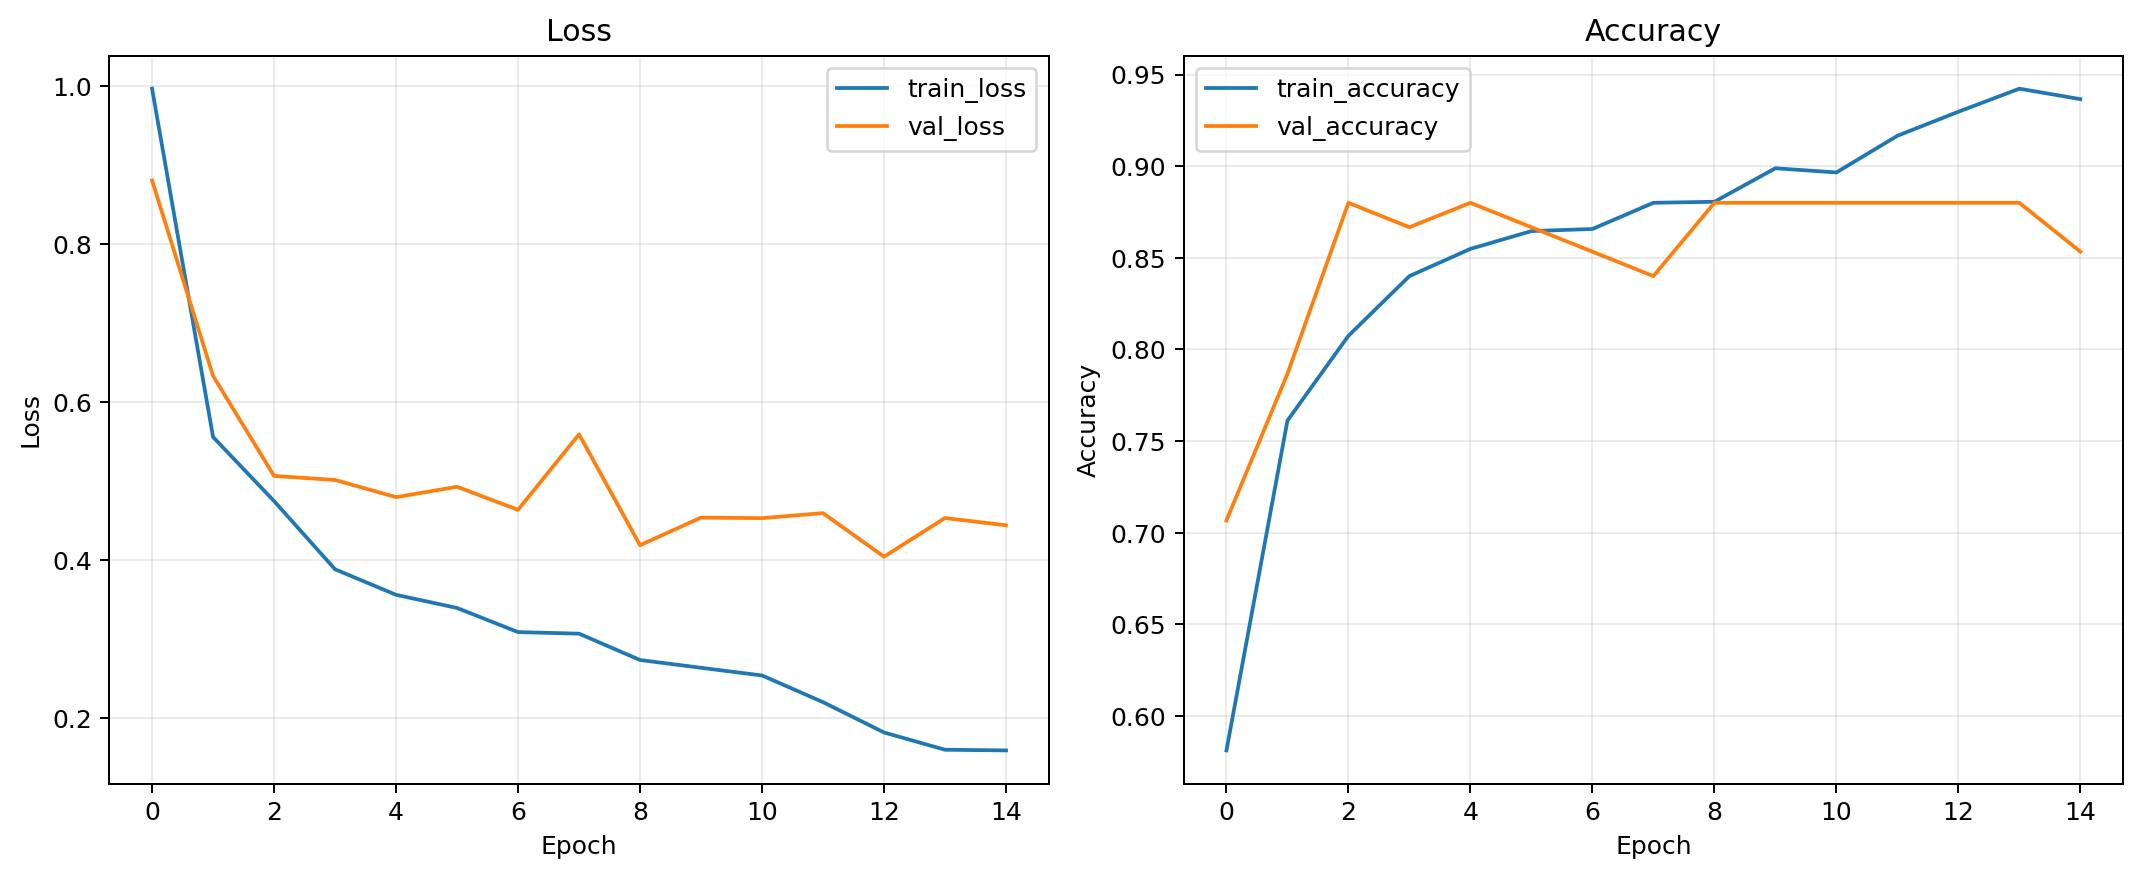


Confusion matrix:


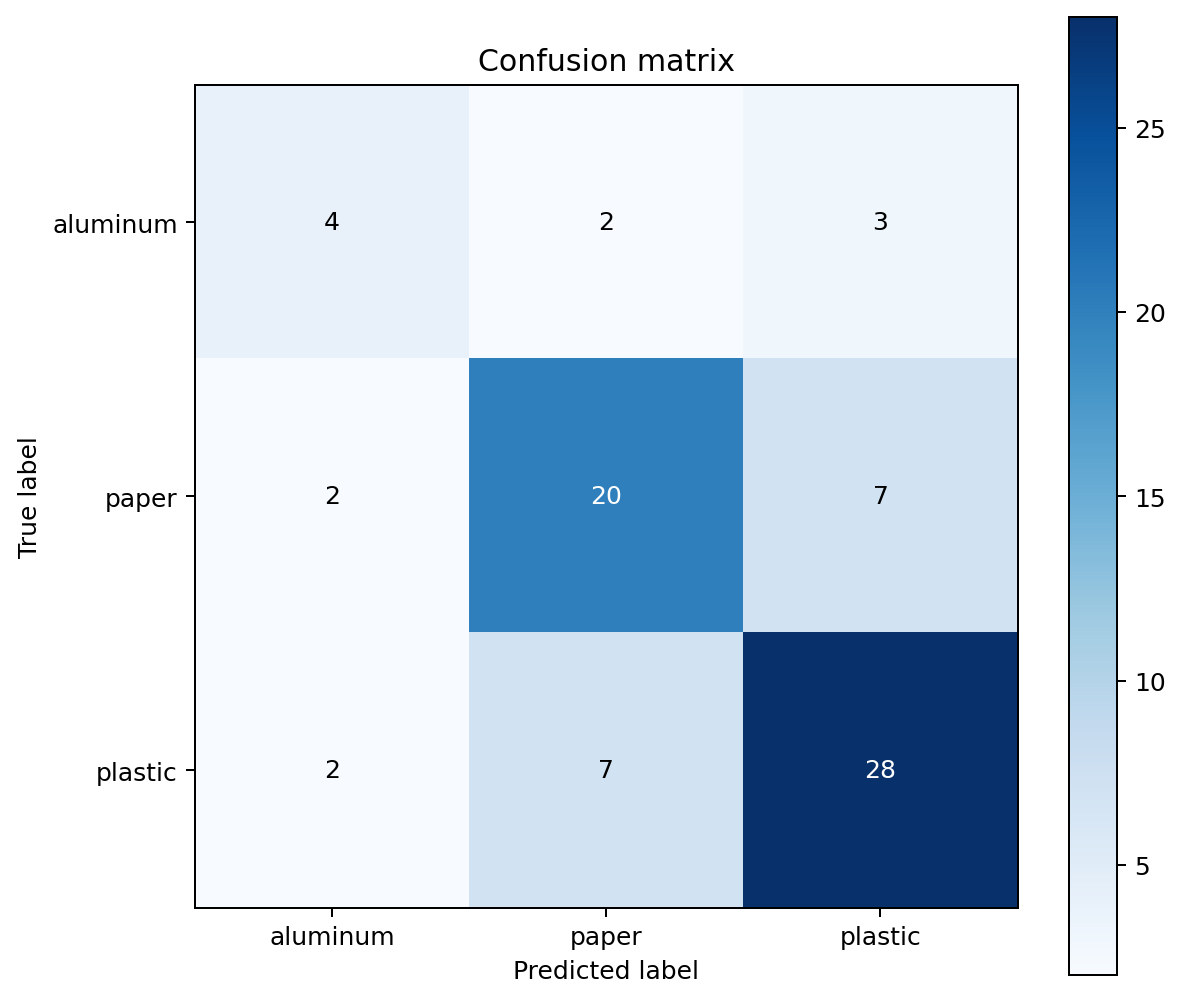


Normalized confusion matrix:


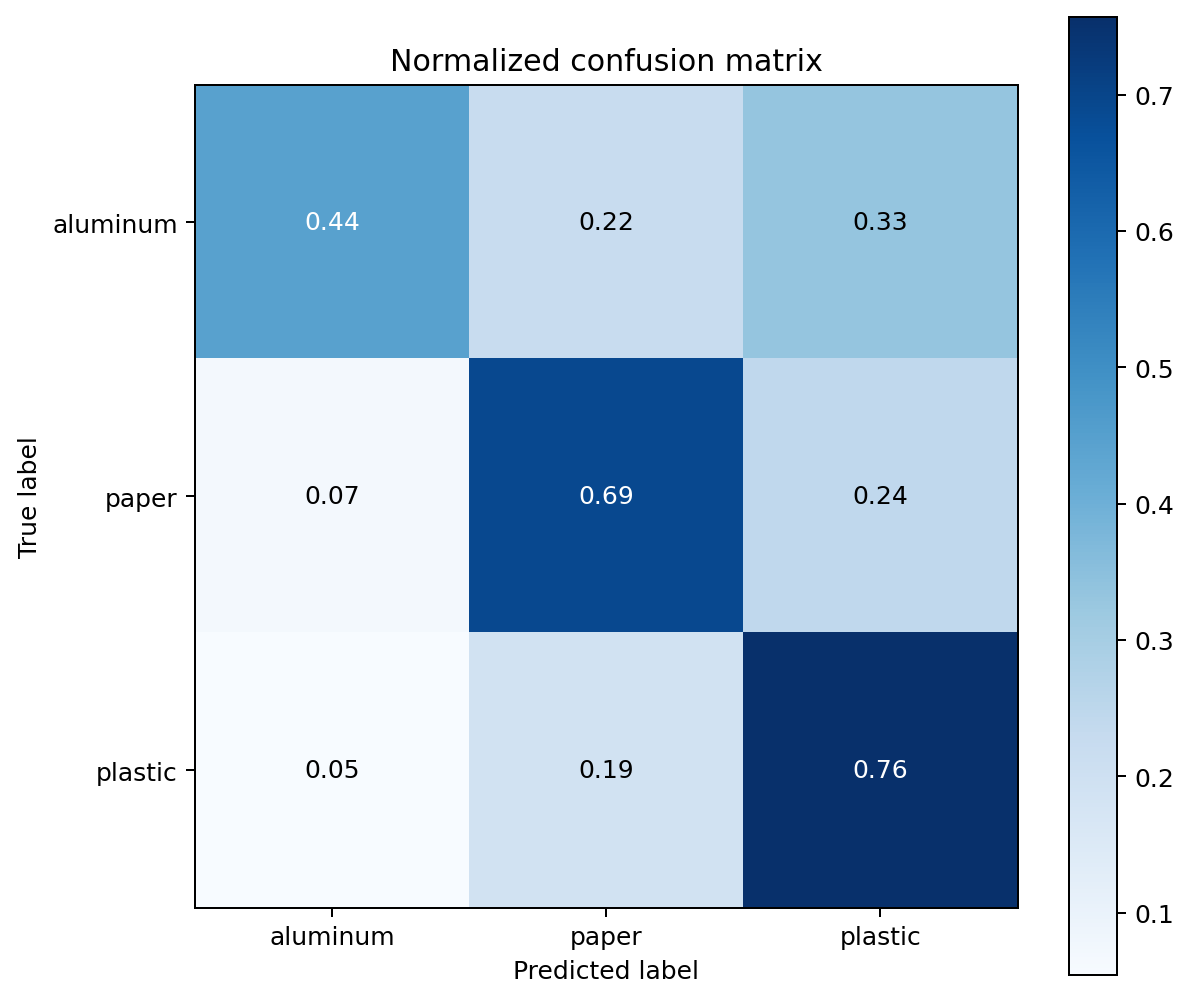



MobileNetV3
Test metrics:
  accuracy: 0.3333333432674408
  loss: 309.6977233886719

Training curves:


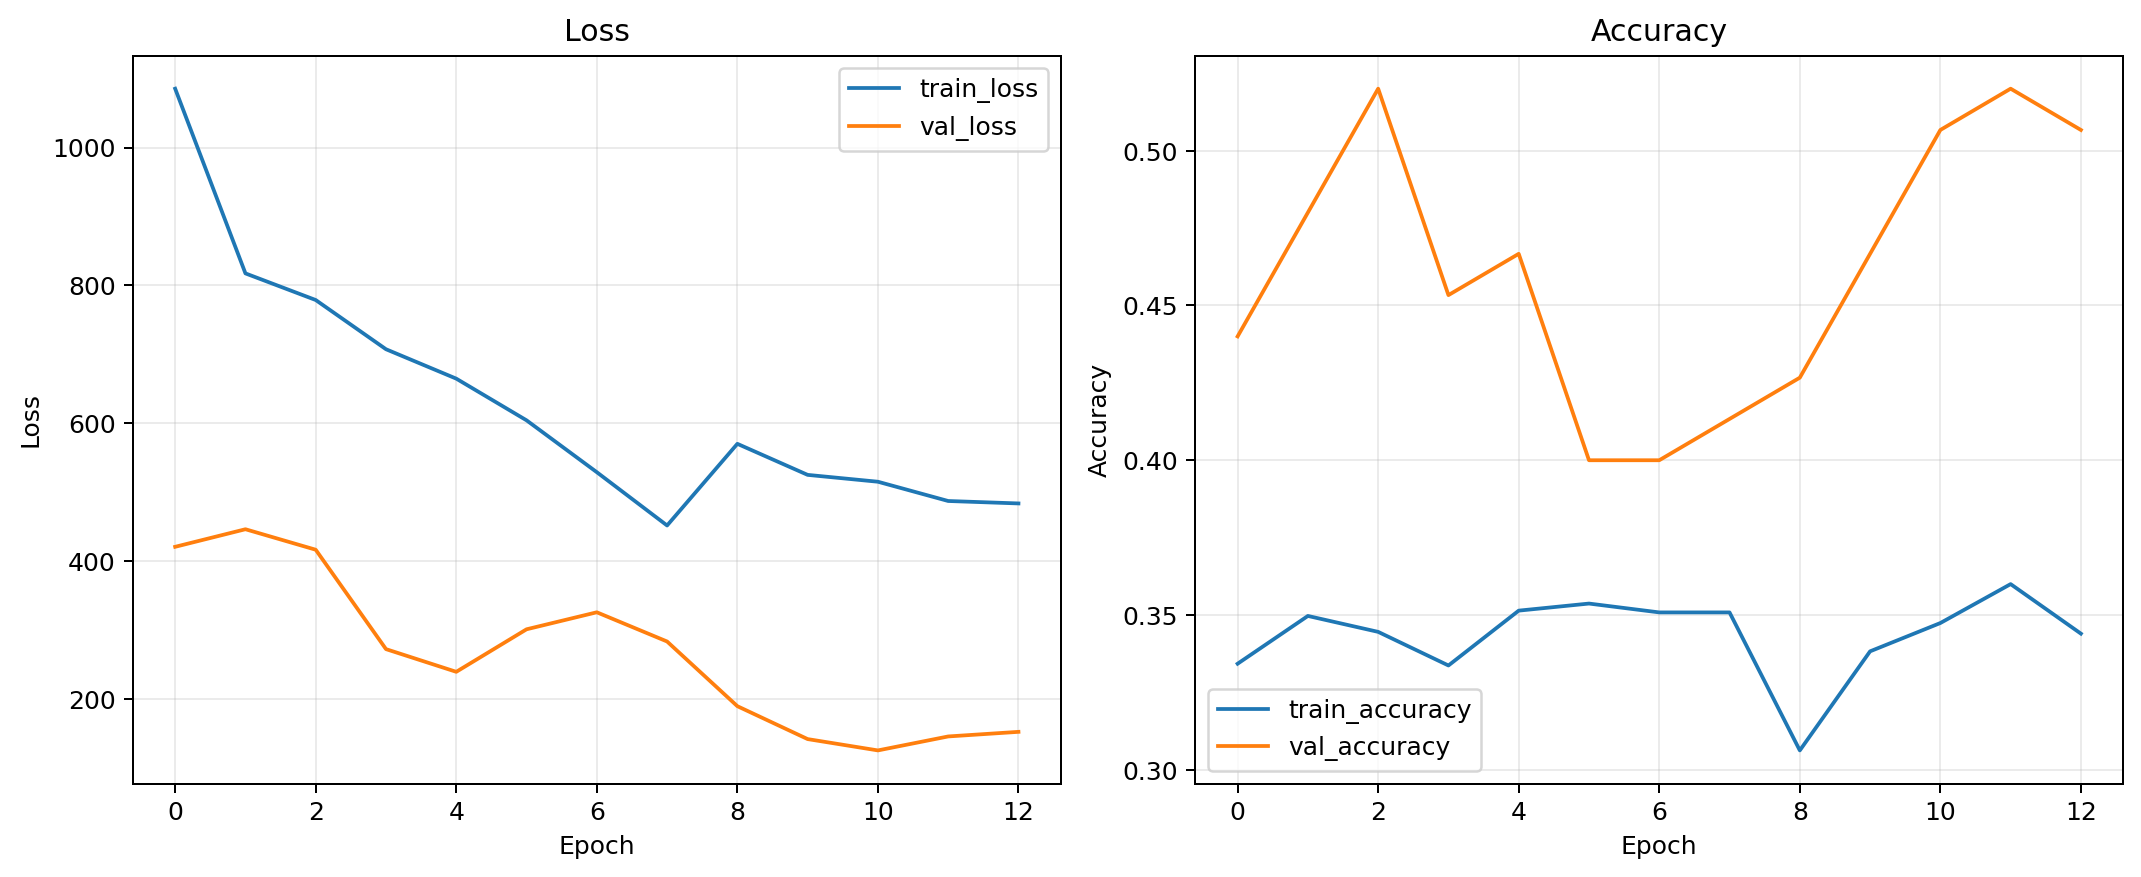


Confusion matrix:


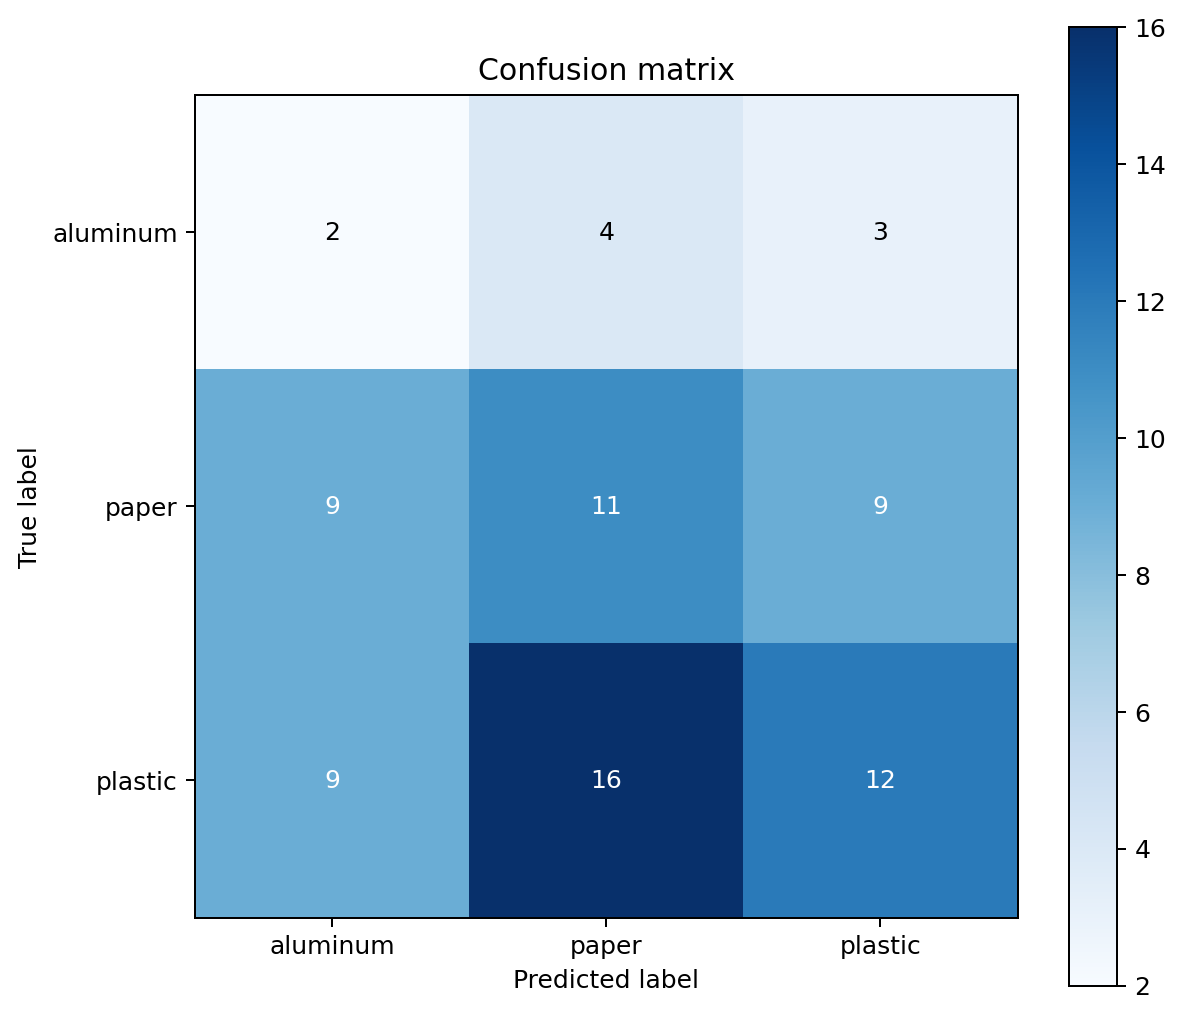


Normalized confusion matrix:


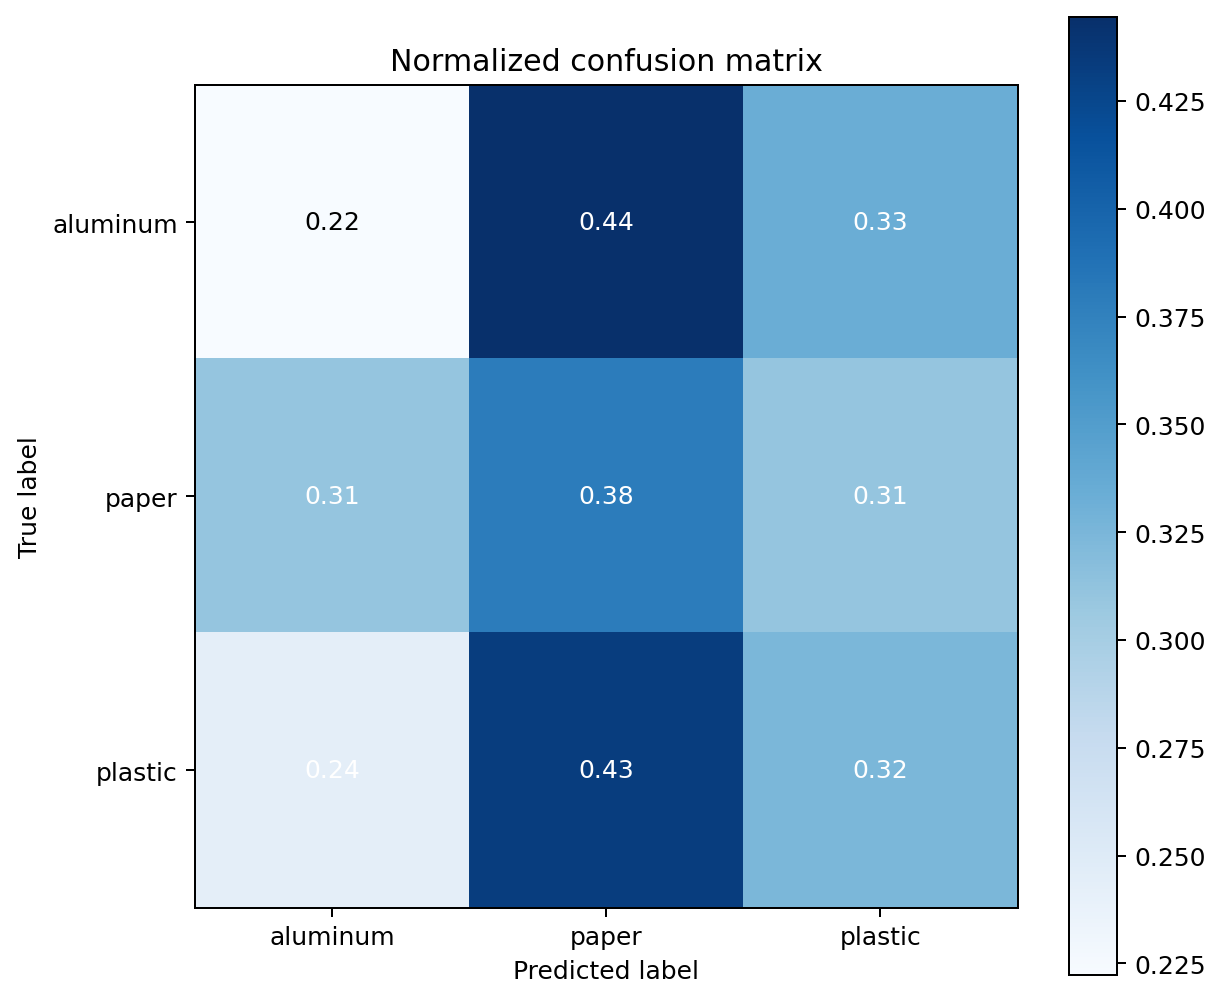



MobileNetV4
Test metrics:
  loss: 2.884480372269948
  accuracy: 0.48

Training curves:


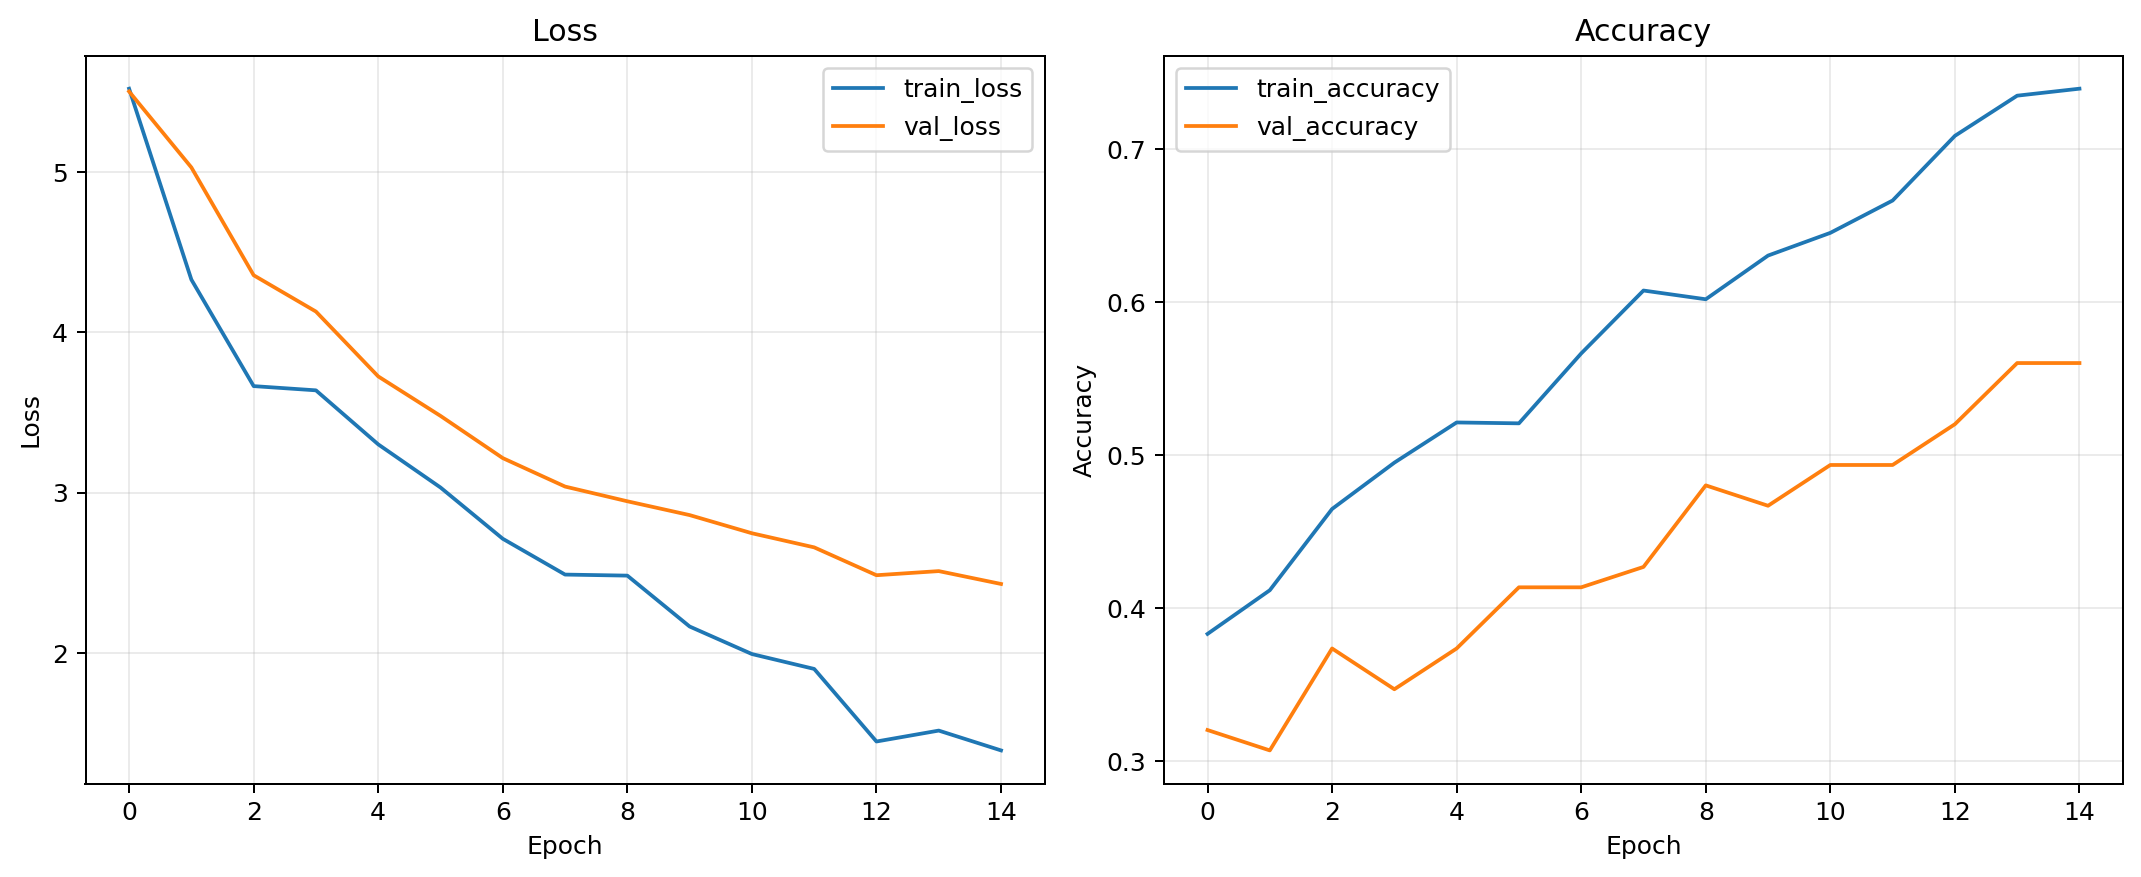


Confusion matrix:


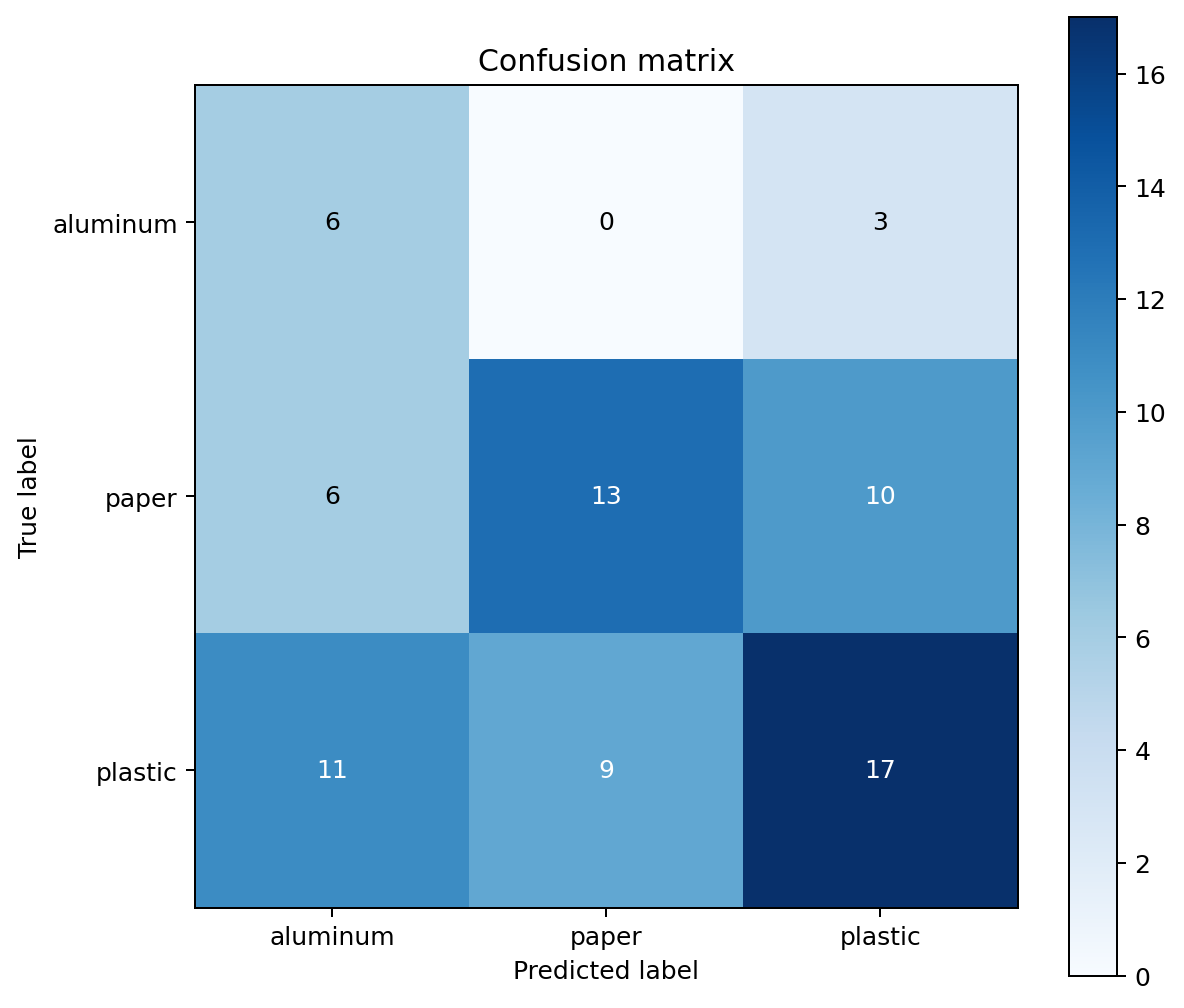


Normalized confusion matrix:


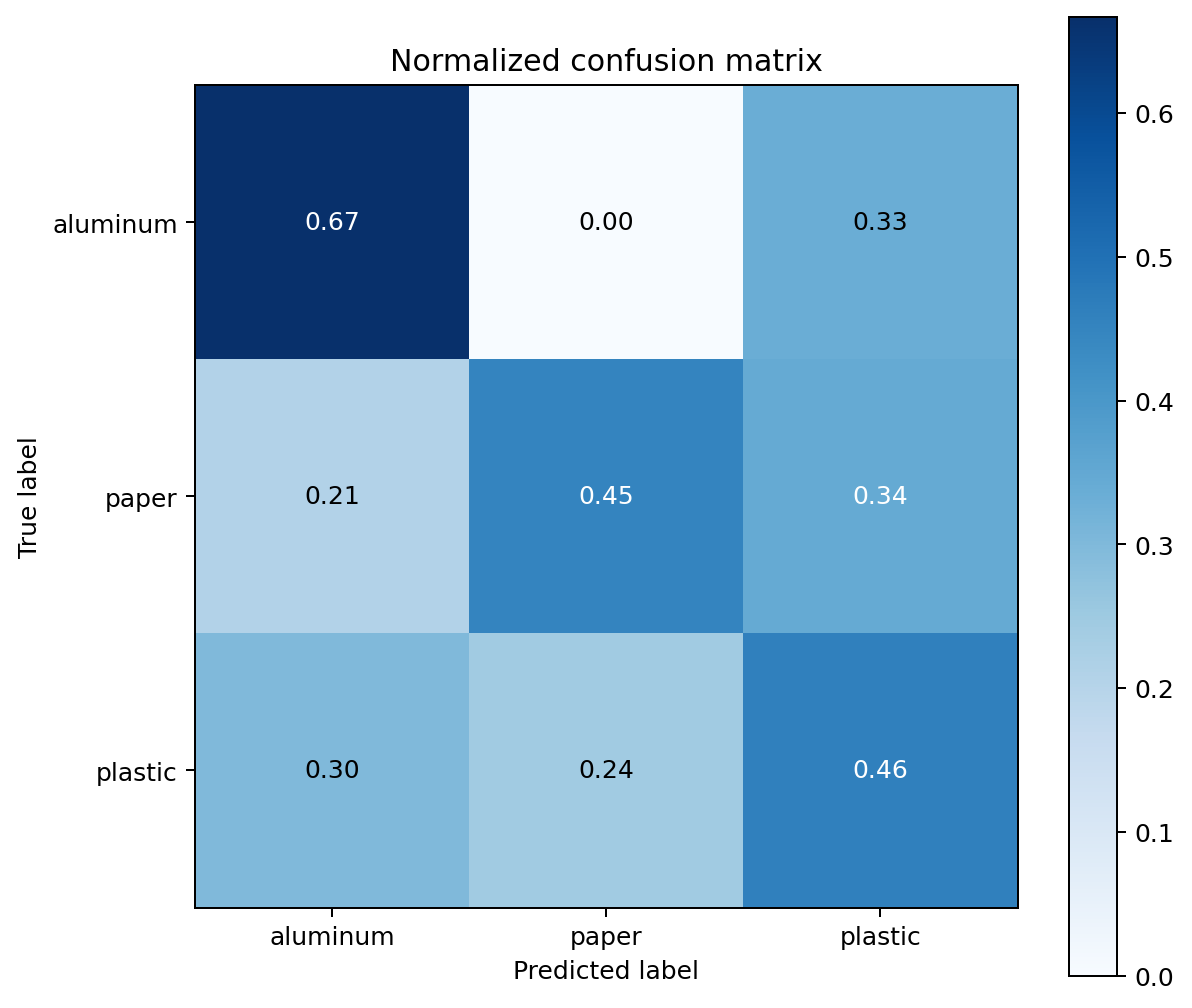

In [17]:
for name, output_dir in runs.items():
    print("=" * 80)
    print(name)
    print("=" * 80)

    metrics_path = output_dir / "test_metrics.json"
    if metrics_path.exists():
        metrics = json.loads(metrics_path.read_text())
        print("Test metrics:")
        for key, value in metrics.items():
            print(f"  {key}: {value}")
    else:
        print("No test_metrics.json found")

    print("\nTraining curves:")
    training_curves = output_dir / "training_curves.png"
    if training_curves.exists():
        display(Image(filename=str(training_curves)))
    else:
        print("No training_curves.png found")

    print("\nConfusion matrix:")
    confusion_matrix = output_dir / "confusion_matrix.png"
    if confusion_matrix.exists():
        display(Image(filename=str(confusion_matrix)))
    else:
        print("No confusion_matrix.png found")

    print("\nNormalized confusion matrix:")
    normalized_confusion_matrix = output_dir / "confusion_matrix_normalized.png"
    if normalized_confusion_matrix.exists():
        display(Image(filename=str(normalized_confusion_matrix)))
    else:
        print("No confusion_matrix_normalized.png found")

    print("\n")